# Priority 2 — Distribution & Error Diagnostics (v9 vs v11)

Makes the model errors interpretable: are the variables normal, does the test set
differ from train, where (which stations / when) does the model struggle.

- **2a** Distribution normality + train-vs-test shift (humidity in focus)
- **2b** Pressure deep-dive: per-station error percentiles + error over time
- **2c** Relative error + per-station spatial discrepancy

Errors are in **physical units** using the exact per-`(station,variable)` scale the
pipeline applied (per-station std, global fallback < 50 obs). Both runs share this scale.

In [1]:
# ── Config ───────────────────────────────────────────────────────────────────
import os, sys, datetime
import numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, os.path.dirname(os.path.abspath(".")))

RESULTS_DIR = "test_results"
VERSIONS    = ["v9", "v11"]
MR          = "mr0.50"
EXCLUDE     = ["PFA"]
MIN_OBS     = 50
from data.dataset import TRAIN_YEARS, TEST_YEARS, VARIABLE_NAMES
VARS  = ["temperature","pressure","humidity","wind_u","wind_v"]
UNITS = {"temperature":"°C","pressure":"hPa","humidity":"%","wind_u":"m/s","wind_v":"m/s"}
COL   = {"v9":"#2E7D8C","v11":"#D9663D"}
_CAND = ["/home/renku/work/PeakWeatherDataset",
         os.path.expanduser("~/Documents/ETH/_DAS Project/PeakWeatherDataset"),
         os.path.expanduser("~/PeakWeatherDataset"),"PeakWeatherDataset"]
DATA_ROOT = next((p for p in _CAND if os.path.isdir(p)), _CAND[-1])
plt.rcParams.update({"figure.dpi":110,"font.size":10})
print("data root:", DATA_ROOT)

data root: /Users/aureliedejong/Documents/ETH/_DAS Project/PeakWeatherDataset


In [2]:
# ── Load predictions (both versions, mr0.50) ─────────────────────────────────
import torch
def load_pred(v):
    d=torch.load(os.path.join(RESULTS_DIR,v,f"best_{MR}","predictions.pt"),
                 map_location="cpu",weights_only=False)
    return {k:(x.numpy() if torch.is_tensor(x) else x) for k,x in d.items()}
PRED={v:load_pred(v) for v in VERSIONS}
N=PRED[VERSIONS[0]]["preds"].shape[2]
GRID=PRED[VERSIONS[0]]["delta_steps"][0].astype(int)
def lead(s):
    m=int(s)*10
    return "t=0" if m==0 else (f"+{m}min" if m<60 else (f"+{m//60}h" if m%60==0 else f"+{m//60}h{m%60:02d}"))
LEAD=[lead(s) for s in GRID]
EPOCH=datetime.datetime(1970,1,1)
print("stations",N,"| horizons",LEAD)

stations 155 | horizons ['t=0', '+30min', '+1h', '+1h30', '+2h', '+2h30', '+3h', '+3h30', '+4h', '+4h30', '+5h', '+5h30', '+6h']


In [3]:
# ── Dataset: coverage → per-(station,var) physical scale, coords, train/test raw ──
from data.dataset import load_peakweather, StationMAEDataset
ds=load_peakweather(root=DATA_ROOT)
order=ds.stations_table.index.tolist()
keep=StationMAEDataset._resolve_keep_indices(ds,EXCLUDE)
kept=[order[i] for i in keep]
assert len(kept)==N

obs=ds.get_observations(parameters=VARIABLE_NAMES); obs.index=pd.to_datetime(obs.index)
train=obs.loc[np.isin(obs.index.year,TRAIN_YEARS)]
test =obs.loc[np.isin(obs.index.year,TEST_YEARS)]
n_tr=len(train)
def mat(s): return s.unstack().reindex(index=kept,columns=VARS).values
cnt=np.nan_to_num(mat(train.notna().sum()),nan=0.0)
sd =mat(train.std()); mn=mat(train.mean())
g_std =np.array([np.nanstd (train.xs(v,axis=1,level=1).values) for v in VARS])
g_mean=np.array([np.nanmean(train.xs(v,axis=1,level=1).values) for v in VARS])
useg=(cnt<MIN_OBS)|~np.isfinite(sd)|(sd<1e-6)
STD=np.clip(np.where(useg,g_std[None,:],sd),1e-6,None)   # (N,5) per-station physical std
# station coordinates (km) for spatial maps
CO=ds.stations_table.loc[kept,["swiss_easting","swiss_northing"]].values/1000.0
print("scale matrix",STD.shape,"| coords",CO.shape)

def err_phys(v, vi):
    """physical error (M,K,N) and sensor mask for version v, variable vi."""
    d=PRED[v]
    e=(d["preds"][...,vi]-d["targets"][...,vi])*STD[None,None,:,vi]
    return e,(d["masks"][...,vi]>0.5)

scale matrix (155, 5) | coords (155, 2)


## 2a. Distribution normality & train-vs-test shift

Is each variable ~normal, and does 2023–24 (test) differ from 2017–21 (train)?
Humidity is bounded 0–100 % and saturates, so a non-normal, skewed shape here is the
signal for a **logit transform**.

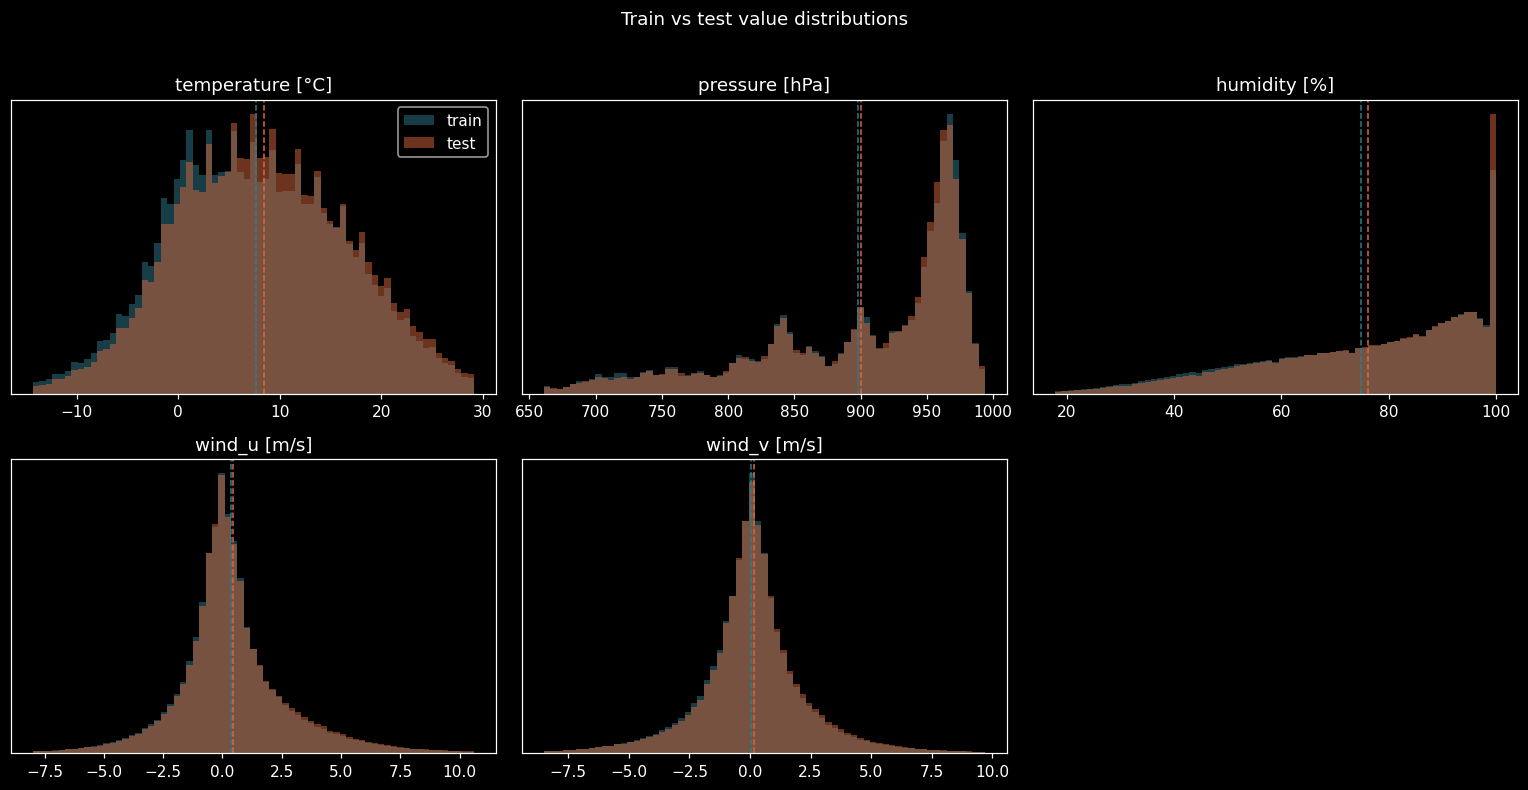

In [4]:
# ── Train vs test distribution per variable (physical) ───────────────────────
fig,axes=plt.subplots(2,3,figsize=(14,7))
for ax,(vi,v) in zip(axes.ravel(),enumerate(VARS)):
    a=train.xs(v,axis=1,level=1).values.ravel(); a=a[~np.isnan(a)]
    b=test .xs(v,axis=1,level=1).values.ravel(); b=b[~np.isnan(b)]
    lo,hi=np.nanpercentile(np.concatenate([a,b]),[0.5,99.5]); bins=np.linspace(lo,hi,70)
    ax.hist(a,bins=bins,density=True,alpha=0.5,color="#2E7D8C",label="train")
    ax.hist(b,bins=bins,density=True,alpha=0.5,color="#D9663D",label="test")
    ax.axvline(a.mean(),color="#2E7D8C",ls="--",lw=1); ax.axvline(b.mean(),color="#D9663D",ls="--",lw=1)
    ax.set_title(f"{v} [{UNITS[v]}]"); ax.set_yticks([])
axes.ravel()[0].legend(); axes.ravel()[-1].axis("off")
fig.suptitle("Train vs test value distributions",y=1.02); plt.tight_layout(); plt.show()

In [5]:
# ── Normality + shift table (skew, excess kurtosis, mean shift) ──────────────
rows={}
for v in VARS:
    a=train.xs(v,axis=1,level=1).stack(); b=test.xs(v,axis=1,level=1).stack()
    rows[v]={"train_mean":a.mean(),"test_mean":b.mean(),"Δmean":b.mean()-a.mean(),
             "train_skew":a.skew(),"test_skew":b.skew(),
             "train_kurt":a.kurt(),"test_kurt":b.kurt()}
tab=pd.DataFrame(rows).T
display(tab.style.format("{:+.2f}").set_caption(
    "Normality (skew≈0 & excess-kurt≈0 ⇒ normal) and train→test mean shift"))

,train_mean,test_mean,Δmean,train_skew,test_skew,train_kurt,test_kurt
temperature,+7.62,+8.45,+0.83,+0.04,+0.05,-0.26,-0.27
pressure,+898.25,+899.83,+1.58,-1.05,-1.08,+0.14,+0.25
humidity,+74.79,+76.11,+1.32,-0.72,-0.78,-0.31,-0.17
wind_u,+0.35,+0.46,+0.11,+0.64,+0.72,+6.20,+5.76
wind_v,+0.06,+0.15,+0.09,+0.40,+0.41,+7.03,+6.69


## 2b. Pressure deep-dive

Per-station error distribution, percentiles of the model error, and error over time.
Flag stations or periods with a systematic discrepancy.
*(Note: the 200 saved windows span Jan–Apr 2023, so the time view covers that period.)*

,p1,p5,p25,p50,p75,p95,p99,MAE,bias
v9,-2.90,-1.97,-0.90,-0.17,+0.64,+1.75,+2.66,+0.93,-0.13
v11,-2.55,-1.62,-0.55,+0.21,+1.03,+2.62,+4.16,+1.01,+0.30


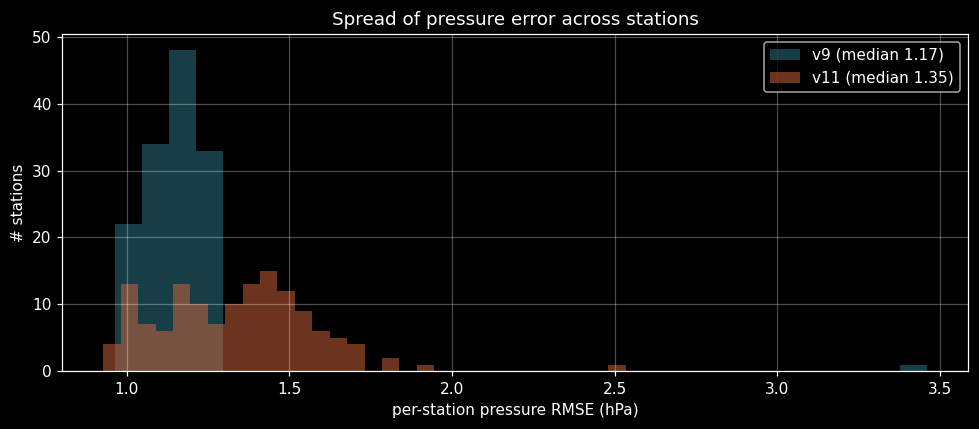

Worst pressure stations (v11): [('BIZ', 2.53), ('BAS', 1.91), ('DEM', 1.83), ('BOU', 1.81), ('AIG', 1.69), ('CRM', 1.69), ('MOE', 1.68), ('MAH', 1.68)]


In [6]:
# ── Pressure: pooled error percentiles + per-station RMSE spread ─────────────
vi=VARS.index("pressure")
pct=[1,5,25,50,75,95,99]
rows={}
per_station_rmse={}
for v in VERSIONS:
    e,m=err_phys(v,vi)
    rows[v]={f"p{p}":np.percentile(e[m],p) for p in pct}
    rows[v]["MAE"]=np.abs(e[m]).mean(); rows[v]["bias"]=e[m].mean()
    ps=np.array([np.sqrt(np.mean(e[:,:,n][m[:,:,n]]**2)) if m[:,:,n].sum()>30 else np.nan
                 for n in range(N)])
    per_station_rmse[v]=ps
display(pd.DataFrame(rows).T.style.format("{:+.2f}")
        .set_caption("Pressure model error — percentiles (hPa)"))

fig,ax=plt.subplots(figsize=(9,4))
for v in VERSIONS:
    ps=per_station_rmse[v]; ps=ps[np.isfinite(ps)]
    ax.hist(ps,bins=30,alpha=0.5,color=COL[v],label=f"{v} (median {np.median(ps):.2f})")
ax.set_xlabel("per-station pressure RMSE (hPa)"); ax.set_ylabel("# stations")
ax.set_title("Spread of pressure error across stations"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
# worst stations (v11)
worst=np.argsort(-np.nan_to_num(per_station_rmse["v11"]))[:8]
print("Worst pressure stations (v11):",
      [(kept[n], round(float(per_station_rmse['v11'][n]),2)) for n in worst])

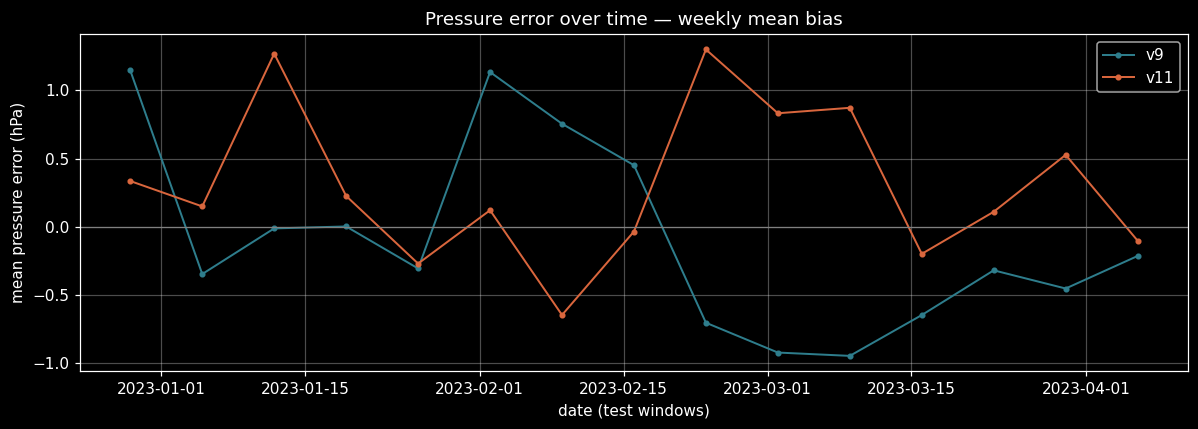

In [7]:
# ── Pressure error over time (weekly mean bias, v9 vs v11) ───────────────────
vi=VARS.index("pressure")
fig,ax=plt.subplots(figsize=(11,4))
for v in VERSIONS:
    d=PRED[v]; e,m=err_phys(v,vi)
    th=d["target_hours"]                       # (M,K) hours since epoch
    hrs=np.broadcast_to(th[:,:,None],e.shape)[m]
    err=e[m]
    days=(hrs/24.0).astype(int)
    wk=days//7
    dfw=pd.DataFrame({"wk":wk,"err":err}).groupby("wk")["err"].mean()
    dates=[EPOCH+datetime.timedelta(days=int(w*7)) for w in dfw.index]
    ax.plot(dates,dfw.values,"o-",color=COL[v],ms=3,lw=1.3,label=v)
ax.axhline(0,color="0.5",lw=0.8); ax.set_ylabel("mean pressure error (hPa)")
ax.set_xlabel("date (test windows)"); ax.set_title("Pressure error over time — weekly mean bias")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 2c. Relative error & per-station spatial discrepancy

Relative error uses error/σ (nMAE) — a stable "fraction of natural variability", since
error/value blows up for zero-crossing variables (temperature, wind). The map shows
*where* the model struggles.

In [8]:
# ── Relative error per variable (nMAE, nRMSE) + physical MAE ─────────────────
rows={}
for v in VERSIONS:
    for vi,var in enumerate(VARS):
        e,m=err_phys(v,vi); ev=e[m]; mae=np.abs(ev).mean(); rmse=np.sqrt(np.mean(ev**2))
        rows[(v,var)]={"MAE":mae,"nMAE=MAE/σ":mae/g_std[vi],"nRMSE=RMSE/σ":rmse/g_std[vi]}
rel=pd.DataFrame(rows).T
rel.index.names=["version","variable"]
display(rel.style.format("{:.3f}").set_caption("Relative error (÷ global σ) — v9 vs v11"))

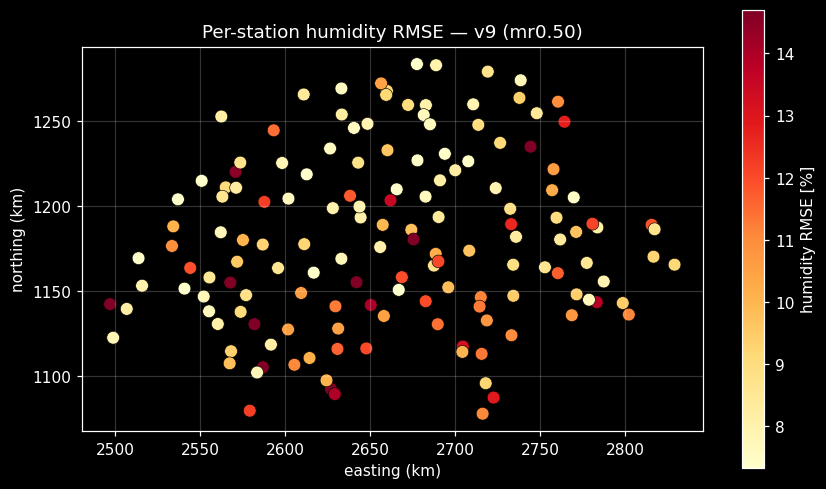

Change MAP_VAR / v at the top of this cell to map other variables or v9.


In [12]:
# ── Per-station spatial discrepancy map ──────────────────────────────────────
MAP_VAR="humidity"; vi=VARS.index(MAP_VAR); v="v9"
e,m=err_phys(v,vi)
ps=np.array([np.sqrt(np.mean(e[:,:,n][m[:,:,n]]**2)) if m[:,:,n].sum()>30 else np.nan
             for n in range(N)])
ok=np.isfinite(ps)
fig,ax=plt.subplots(figsize=(8,5.5))
sc=ax.scatter(CO[ok,0],CO[ok,1],c=ps[ok],cmap="YlOrRd",s=70,edgecolors="k",linewidths=0.4,
              vmin=np.nanpercentile(ps,5),vmax=np.nanpercentile(ps,95))
plt.colorbar(sc,ax=ax,label=f"{MAP_VAR} RMSE [{UNITS[MAP_VAR]}]",shrink=0.8)
ax.set_xlabel("easting (km)"); ax.set_ylabel("northing (km)"); ax.set_aspect("equal")
ax.set_title(f"Per-station {MAP_VAR} RMSE — {v} (mr0.50)"); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()
print("Change MAP_VAR / v at the top of this cell to map other variables or v9.")